# SlideAgent Baseline — Báo cáo Experiment

**Mục tiêu**
- Chạy baseline SlideAgent trên **một tác vụ dynamic slide update thật**.
- Đối chiếu **code đã hiện thực ↔ paper** (đúng / thiếu, kèm reference).
- PoC bước **render slide** (repo bỏ trống) bằng workflow agent-skill.

**Nguồn:** paper arXiv 2604.17894v1 · code `github.com/XiaoZhou2024/SlideAgent`, đóng gói thành package `slideagent` (thêm từ root: `uv add packages/SlideAgent`) → import `from slideagent...`.

In [ ]:
import os, copy, json
from pathlib import Path
import pandas as pd, yaml
from dotenv import load_dotenv

SA = Path("../../packages/SlideAgent")
os.chdir(SA)                       # prompts/, ReSlide/, data/ resolve theo CWD
load_dotenv(SA / ".env")
print("cwd  :", os.getcwd())
print("model:", os.getenv("MODEL_NAME"))

cwd  : /Users/ngotai/CodeSpace/research_slide_gen/packages/SlideAgent
model: inclusionai/ling-3.0-flash


## 1. Tạo task (sandbox, grounded trên Postgres local)

- Dataset DynaSlide + dump Postgres **không public** → dựng 1 task tối thiểu, tự chứa.
- Slide nguồn: `title` + `kết luận` + `caption` + **bảng phân bố diện tích**.
- Lệnh: *"generate a slide for Beijing Liangxiang, 2020–2022"*.

In [2]:
import random, csv
import psycopg2
from pptx import Presentation
from pptx.util import Cm, Pt

random.seed(7)
TASK = SA / "ReSlide/test/ReSlide_01/theme1/template-1/temp"; TASK.mkdir(parents=True, exist_ok=True)
PPTX, GT, CSV = TASK/"source.pptx", TASK/"source.yaml", TASK/"filename_to_label.csv"

# --- seed bảng Postgres local: 3000 bản ghi giao dịch tổng hợp ---
conn = psycopg2.connect(dbname=os.getenv("DB_NAME"), user=os.getenv("DB_USER"),
                        password=os.getenv("DB_PASSWORD") or None,
                        host=os.getenv("DB_HOST"), port=os.getenv("DB_PORT"))
conn.autocommit = True; cur = conn.cursor()
cur.execute("DROP TABLE IF EXISTS beijing_new_house;")
cur.execute("""CREATE TABLE beijing_new_house(
  city text, block text, project text, date_code date, supply_sets int, trade_sets int,
  dim_area double precision, dim_price double precision, dim_unit_price double precision);""")
rows = []
for _ in range(3000):
    y = random.choice([2020,2021,2022]); m = random.randint(1,12); d = random.randint(1,28)
    area = round(random.triangular(10,300,90),1); up = random.randint(28000,52000)
    rows.append(("Beijing","Liangxiang","Liangxiang Project", f"{y}-{m:02d}-{d:02d}",
                 random.choice([0,1,1]), random.choice([0,1]), area, round(area*up/1e4,1), up))
cur.executemany("INSERT INTO beijing_new_house VALUES (%s,%s,%s,%s,%s,%s,%s,%s,%s)", rows)
cur.close(); conn.close()

# --- .pptx nguồn: thứ tự shape = slide-title, body-text, caption, table ---
prs = Presentation(); prs.slide_width, prs.slide_height = Cm(33.87), Cm(19.05)
slide = prs.slides.add_slide(prs.slide_layouts[6])
def tb(x,y,w,h,t,s=18,b=False):
    r = slide.shapes.add_textbox(Cm(x),Cm(y),Cm(w),Cm(h)).text_frame; r.text=t
    r.paragraphs[0].runs[0].font.size=Pt(s); r.paragraphs[0].runs[0].font.bold=b
tb(1.5,0.8,30,2,"Beijing Liangxiang New House Market Report",24,True)
tb(1.5,3.0,15,4,"From 2020-2022, Liangxiang's core supply-demand area was 80-100m2, "
                "with upgraded units centered on 160-180m2.",14)
tb(1.5,7.4,20,1.2,"2020-2022 Supply and Transaction Unit Statistics in Beijing's Liangxiang",14,True)
bins = [f"{i}-{i+20}m2" for i in range(0,300,20)]
tobj = slide.shapes.add_table(len(bins)+1,3,Cm(1.5),Cm(8.6),Cm(20),Cm(10.0)).table
def _cell(cell,text,size=10,bold=False):     # font nhỏ + margin sát để 16 dòng vừa khung, không tràn slide
    cell.margin_left=Cm(0.1); cell.margin_right=Cm(0.1); cell.margin_top=Cm(0.01); cell.margin_bottom=Cm(0.01)
    cell.text=text; r=cell.text_frame.paragraphs[0].runs[0]; r.font.size=Pt(size); r.font.bold=bold
for c,h in enumerate(["area_range","Supply Count","Trans Count"]): _cell(tobj.cell(0,c),h,10,True)
for i,b in enumerate(bins,1):
    _cell(tobj.cell(i,0),b); _cell(tobj.cell(i,1),str(random.randint(0,200))); _cell(tobj.cell(i,2),str(random.randint(0,200)))
prs.save(PPTX)

template_slide = {"slide_size":{"width":33.87,"height":19.05},"elements":[
  {"type":"text","role":"slide-title","layout":{"x":1.5,"y":0.8,"width":30,"height":2},
   "text":"Beijing Liangxiang New House Market Report"},
  {"type":"text","role":"body-text","layout":{"x":1.5,"y":3.0,"width":15,"height":4},
   "text":"From 2020-2022, Liangxiang's core supply-demand area was 80-100m2, with upgraded units centered on 160-180m2."},
  {"type":"text","role":"caption","layout":{"x":1.5,"y":8.0,"width":20,"height":1.2},
   "text":"2020-2022 Supply and Transaction Unit Statistics in Beijing's Liangxiang"},
  {"type":"table","role":"table","layout":{"x":1.5,"y":9.5,"width":14,"height":9}}]}
GT.write_text(yaml.safe_dump({"template_slide":template_slide,"output_slide":{"content_elements":[]}},
                             allow_unicode=True, sort_keys=False), encoding="utf-8")
query = "Based on this slide, please generate a slide for the Beijing Liangxiang sector from 2020 to 2022."
with open(CSV,"w",newline="",encoding="utf-8") as f: csv.writer(f).writerow([str(PPTX),query,str(GT)])
print("seed 3000 dòng; task ghi tại", TASK.name)

seed 3000 dòng; task ghi tại temp


## 2. Chạy baseline (SlideAgent như thư viện)

Khởi tạo các class pipeline, chạy 2 stage, in từng output trung gian.

In [3]:
from slideagent.file_utils import read_report_tasks_from_csv
from slideagent.sql_generator import SqlGenerator
from slideagent.tools_selector import ToolSelector
from slideagent.conclusion_generator import ConclusionGenerator
from slideagent.database_manager import DatabaseManager
from slideagent.yaml_processor import YamlProcessor

task = read_report_tasks_from_csv(CSV)[0]
proc = YamlProcessor(task, SqlGenerator(), DatabaseManager(), ToolSelector(), ConclusionGenerator())

def _retry(fn, n=4):                    # model rẻ thỉnh thoảng ra JSON hỏng (B5) -> thử lại
    err = None
    for _ in range(n):
        try: return fn()
        except Exception as e: err = e
    raise err

print("lệnh:", task.query)

lệnh: Based on this slide, please generate a slide for the Beijing Liangxiang sector from 2020 to 2022.


### Stage 1 — Hiểu slide (parse lệnh · data source · logic hàm)

In [4]:
# gọi trực tiếp phần thân parse_ppt() (mỗi call bọc _retry cho ổn định)
qf   = _retry(lambda: proc.sql_generator.generate_datasource_json(task.query))   # lệnh -> params mới
tmpl = proc.load_yaml_data(task.ground_truth_yaml_path)                          # cấu trúc slide + dữ liệu bảng
sf   = _retry(lambda: proc.sql_generator.get_slide_filters_json(tmpl))           # tái dựng data source slide gốc
sf   = _retry(lambda: proc.pptx_parser._match_caption_and_table1(tmpl, sf))      # logic hàm -> four-tuple
uf   = proc.sql_generator.process_update_filters(qf, sf)                          # gộp lệnh vào slide gốc

print("query_filters :", qf)
print("data source   :", sf[0]["connection"], sf[0]["select_columns"])
print("logic hàm     :", sf[0]["fun_tool"]["quadruples"])

query_filters : {'city': 'Beijing', 'block': 'Liangxiang', 'project': 'default', 'start_date': '2020-01-01', 'end_date': '2022-12-31', 'area_range_size': 'default', 'price_range_size': 'default'}
data source   : {'table': 'beijing_new_house'} ['supply_sets', 'trade_sets', 'dim_area']
logic hàm     : ['field-constraint', [['Supply Count', 'Trans Count'], ['area_range', '{}-{}m2', '0', '300', 20]], [['dim_area', 'supply_sets'], ['dim_area', 'trade_sets']], ['count', 'count']]


### Stage 2 — Truy vấn SQL · tính lại bảng · tóm tắt fact-aware

In [5]:
sqls, data_path = proc.generate_sql(copy.deepcopy(uf))
if not (Path(data_path) / "retrieval" / "0.csv").exists():   # SQL-LLM hỏng (B5) -> dựng SQL trực tiếp từ update_filters
    f = uf[0]; flt = f["filters"]
    conds = [f"{k} = '{flt[k]}'" for k in ("city","block","project") if flt.get(k) not in (None,"default")]
    if flt.get("start_date") not in (None,"default"): conds.append(f"date_code >= '{flt['start_date']}'")
    if flt.get("end_date")   not in (None,"default"): conds.append(f"date_code <= '{flt['end_date']}'")
    sqls = [[f"SELECT {', '.join(f['select_columns'])} FROM public.{f['connection']['table']} WHERE " + " AND ".join(conds)]]
    proc.database_manager.execute_query_save_data(sqls, Path(data_path))
    print("(fallback) SQL dựng trực tiếp")
for i, q in enumerate(sqls): uf[i]["sql_query"] = copy.deepcopy(q)
print("SQL:", sqls[0][0])

uf = proc.generate_tool_call_params(copy.deepcopy(qf), copy.deepcopy(uf), data_path)  # ReAct agent gọi execute_analysis
xlsx = Path(data_path) / "processed" / "0.xlsx"
if not xlsx.exists():                                     # fallback nếu agent không phát tool call (B5)
    from slideagent.tool_functions import execute_analysis
    xlsx.parent.mkdir(parents=True, exist_ok=True)
    csv0 = str(Path(data_path) / "retrieval" / "0.csv")
    CANON = ["field-constraint", [["Supply Count","Trans Count"], ["area_range","{}-{}m²","0","300",20]],
             [["dim_area","supply_sets"],["dim_area","trade_sets"]], ["count","count"]]
    try:
        execute_analysis(json.dumps(uf[0]["fun_tool"]["quadruples"], ensure_ascii=False), csv0, str(xlsx), 1, 20)
        print("(fallback) execute_analysis với quadruples do LLM sinh")
    except Exception as e:                                # quadruples LLM lệch -> dùng canonical
        execute_analysis(json.dumps(CANON, ensure_ascii=False), csv0, str(xlsx), 1, 20)
        print(f"(fallback) quadruples LLM lỗi ({type(e).__name__}) -> dùng canonical")
recomputed = pd.read_excel(xlsx)                          # bảng tính lại từ DB
recomputed

  -> slide_params: {'connection': {'table': 'beijing_new_house'}, 'select_columns': ['supply_sets', 'trade_sets', 'dim_area'], 'filters': {'city': 'Beijing', 'block': 'Liangxiang', 'project': 'default', 'start_date': '2020-01-01', 'end_date': '2022-12-31', 'area_range_size': 'default', 'price_range_size': 'default'}}


Retrieval file written to /Users/ngotai/CodeSpace/research_slide_gen/packages/SlideAgent/data/20260820_205444/retrieval/0.csv
SQL: SELECT supply_sets, trade_sets, dim_area FROM public.beijing_new_house WHERE city = 'Beijing' AND block = 'Liangxiang' AND date_code >= '2020-01-01' AND date_code <= '2022-12-31'
{'options_json': '["field-constraint", [["Supply Count", "Trans Count"], ["area_range", "{}-{}m2", "0", "300", 20]], [["dim_area", "supply_sets"], ["dim_area", "trade_sets"]], ["count", "count"]]', 'input_path': '/Users/ngotai/CodeSpace/research_slide_gen/packages/SlideAgent/data/20260820_205444/retrieval/0.csv', 'output_path': '/Users/ngotai/CodeSpace/research_slide_gen/packages/SlideAgent/data/20260820_205444/processed/0.xlsx', 'price_range_size': 1, 'area_range_size': 20}


result：
    area_range  Supply Count  Trans Count
0      0-20m²             5            4
1     20-40m²            71           65
2     40-60m²           139          101
3     60-80m²           213          152
4    80-100m²           249          177
5   100-120m²           247          183
6   120-140m²           217          170
7   140-160m²           174          142
8   160-180m²           185          128
9   180-200m²           150          116
10  200-220m²           127          103
11  220-240m²            90           69
12  240-260m²            55           48
13  260-280m²            36           26
14  280-300m²            14           10
supply_and_sales_counts_and_share executed successfully, data has been saved to Excel file: /Users/ngotai/CodeSpace/research_slide_gen/packages/SlideAgent/data/20260820_205444/processed/0.xlsx


execute_analysis
{'input_path': '/Users/ngotai/CodeSpace/research_slide_gen/packages/SlideAgent/data/20260820_205444/retrieval/0.csv', 'output_path': '/Users/ngotai/CodeSpace/research_slide_gen/packages/SlideAgent/data/20260820_205444/processed/0.xlsx', 'price_range_size': 1, 'area_range_size': 20, 'options': '["field-constraint", [["Supply Count", "Trans Count"], ["area_range", "{}-{}m2", "0", "300", 20]], [["dim_area", "supply_sets"], ["dim_area", "trade_sets"]], ["count", "count"]]'}
[{'connection': {'table': 'beijing_new_house'}, 'select_columns': ['supply_sets', 'trade_sets', 'dim_area'], 'filters': {'city': 'Beijing', 'block': 'Liangxiang', 'project': 'default', 'start_date': '2020-01-01', 'end_date': '2022-12-31', 'area_range_size': 'default', 'price_range_size': 'default'}, 'fun_tool': {'quadruples': ['field-constraint', [['Supply Count', 'Trans Count'], ['area_range', '{}-{}m2', '0', '300', 20]], [['dim_area', 'supply_sets'], ['dim_area', 'trade_sets']], ['count', 'count']], '

,area_range,Supply Count,Trans Count
0,0-20m²,5,4
1,20-40m²,71,65
2,40-60m²,139,101
3,60-80m²,213,152
4,80-100m²,249,177
5,100-120m²,247,183
6,120-140m²,217,170
7,140-160m²,174,142
8,160-180m²,185,128
9,180-200m²,150,116


In [6]:
for _ in range(4):                      # generate_conclusion nuốt lỗi trả '' -> lặp tới khi có dict hợp lệ
    out = proc.generate_conclusion(copy.deepcopy(qf), copy.deepcopy(tmpl), data_path)
    if isinstance(out, dict) and out.get("elements"): break
conclusion = [e["text"] for e in out["elements"] if e["role"] == "body-text"][0]
print("kết luận tự sinh:\n ", conclusion)

# kiểm chứng độc lập: tóm tắt có bám đúng bảng đã tính lại không
df = recomputed.copy(); df["tot"] = df["Supply Count"] + df["Trans Count"]
core = df.loc[df["tot"].idxmax(), "area_range"]
ge140 = df[df["area_range"].str.extract(r"(\d+)").astype(int)[0] >= 140]
upgraded = ge140.loc[ge140["tot"].idxmax(), "area_range"]
print("kỳ vọng  core supply-demand area:", core)
print("kỳ vọng  upgraded-units area    :", upgraded)

kết luận tự sinh:
  From 2020-2022, Liangxiang's core supply-demand area was 100-120m², with upgraded units centered on 140-160m².
kỳ vọng  core supply-demand area: 100-120m²
kỳ vọng  upgraded-units area    : 140-160m²


## 3. Code đã hiện thực ↔ paper

### A. Có & khớp paper (đã verify ở trên)

| Bước (paper) | Code | Đã verify |
|---|---|---|
| Parse lệnh → state (§4.2.1) | `slideagent/sql_generator.py:89` | ra params mới |
| Trích data source (§4.1.2) | `slideagent/sql_generator.py:122` | ra table + cột |
| Logic hàm → four-tuple (§4.1.2) | `slideagent/pptx_parser2.py:466` | ra quadruples |
| Sinh SQL + retrieval (§4.2.2) | `slideagent/sql_generator.py:54` + `slideagent/database_manager.py:44` | SQL → Postgres → csv |
| Gọi tool + tính lại (§4.2.3) | `slideagent/tools_selector.py:19` → `slideagent/tool_functions.py:8` | bảng tính lại từ DB |
| Tóm tắt fact-aware (§4.2.4) | `slideagent/conclusion_generator.py:73` | kết luận khớp bảng recompute |

### B. Thiếu / lệch so với paper

| # | Paper | Code thực tế | Reference |
|---|---|---|---|
| B1 | Render giữ visual design (§4.2.4); EasySlide (App A.5) | output là YAML `output_slide`, **không render `.pptx`** | `slideagent/yaml_processor.py:217` |
| B2 | **11 hàm** closed-domain làm tool (§4.1.2); Table 1 cột `Cls` | chỉ 1 tool generic `execute_analysis` | `slideagent/tools_selector.py:21`; `slideagent/tool_functions.py:8` |
| B3 | Parse đa mô thức VLM + IoU ≥0.5, 99.5% (§4.1.1) | mặc định bỏ VLM (đọc GT YAML); IoU bị comment, dùng nearest-point | `slideagent/yaml_processor.py:51`; `slideagent/pptx_parser2.py:484,516` |
| B4 | SR + Element-Level Accuracy (§5.2) | không có script eval trong repo | — |
| B5 | Serve model qua vLLM local (App C.1) | `max_retries=0`; call lỗi vẫn in "thành công" | `slideagent/sql_generator.py:103`; `slideagent/yaml_processor.py:104` |

## 4. Bước render còn thiếu — PoC bằng agent-skill (bù B1)

Biến `output_slide` thành `.pptx` bằng **edit-in-place** (giữ text là text, gán `run.text`) → giữ nguyên
layout / font / màu của deck gốc.

In [7]:
from pptx import Presentation
from pptx.enum.shapes import MSO_SHAPE_TYPE
from math import hypot

SRC = TASK / "source.pptx"; OUT = TASK / "output.pptx"
text_elems  = [e for e in out["elements"] if e.get("type") == "text"]
table_elems = [e for e in out["elements"] if e.get("type") == "table"]

def set_run(par, text):                 # đổi text nhưng giữ định dạng của run đầu
    if par.runs:
        par.runs[0].text = text
        for r in par.runs[1:]: r.text = ""
    else:
        par.text = text

prs = Presentation(str(SRC)); slide = prs.slides[0]
texts, tables = [], []
for sh in slide.shapes:
    pos = (sh.left/360000.0, sh.top/360000.0)
    if sh.shape_type == MSO_SHAPE_TYPE.TABLE:
        tables.append((pos, sh))
    elif sh.has_text_frame:
        texts.append((pos, sh))
near = lambda p, pool: min(pool, key=lambda it: hypot(it[0][0]-p[0], it[0][1]-p[1]))[1]

# text: ghép element với textbox gần nhất theo toạ độ, chỉ đổi khi nội dung khác
for e in text_elems:
    sh = near((e["layout"]["x"], e["layout"]["y"]), texts)
    if sh.text_frame.text.strip() != e["text"].strip():
        set_run(sh.text_frame.paragraphs[0], e["text"])

# bảng: ghi đè các dòng body bằng số recompute, giữ header + style
e = table_elems[0]; tb = near((e["layout"]["x"], e["layout"]["y"]), tables).table
hdr = [tb.cell(0,c).text.strip() for c in range(len(tb.columns))]
for i, row in enumerate(e["data"][:len(tb.rows)-1]):
    keys = list(row.keys())
    for c, h in enumerate(hdr):
        set_run(tb.cell(i+1,c).text_frame.paragraphs[0], str(row.get(h, row.get(keys[c], ""))))
prs.save(str(OUT)); print("đã ghi", OUT.name)

đã ghi output.pptx


In [8]:
# kiểm tra: giữ định dạng VÀ cập nhật số
p = Presentation(str(OUT)); s = p.slides[0]
for sh in s.shapes:
    if sh.shape_type == MSO_SHAPE_TYPE.TABLE:
        t = sh.table
        print("[TABLE] header:", [t.cell(0,c).text for c in range(len(t.columns))])
        for i in (1,2,3): print("   dòng", i, [t.cell(i,c).text for c in range(len(t.columns))])
    elif sh.has_text_frame and sh.text.strip():
        r = sh.text_frame.paragraphs[0].runs
        fs = r[0].font.size.pt if (r and r[0].font.size) else None
        print(f"[TEXT] size={fs} bold={r[0].font.bold if r else None} :: {sh.text[:66]}")

[TEXT] size=24.0 bold=True :: Beijing Liangxiang New House Market Report
[TEXT] size=14.0 bold=False :: From 2020-2022, Liangxiang's core supply-demand area was 100-120m²
[TEXT] size=14.0 bold=True :: 2020-2022 Beijing Liangxiang Supply and Transaction Unit Statistic
[TABLE] header: ['area_range', 'Supply Count', 'Trans Count']
   dòng 1 ['0-20m²', '5', '4']
   dòng 2 ['20-40m²', '71', '65']
   dòng 3 ['40-60m²', '139', '101']


## 5. Visual QA (skill: render slide + kiểm tra overflow)

Tái dùng script của agent-skill (`render_slides.py`, `slides_test.py` trong `openai-slides-skill`) để render
`.pptx` → ảnh (bằng chứng cho B1) và kiểm tra nội dung có tràn khung không.

BEFORE — source.pptx


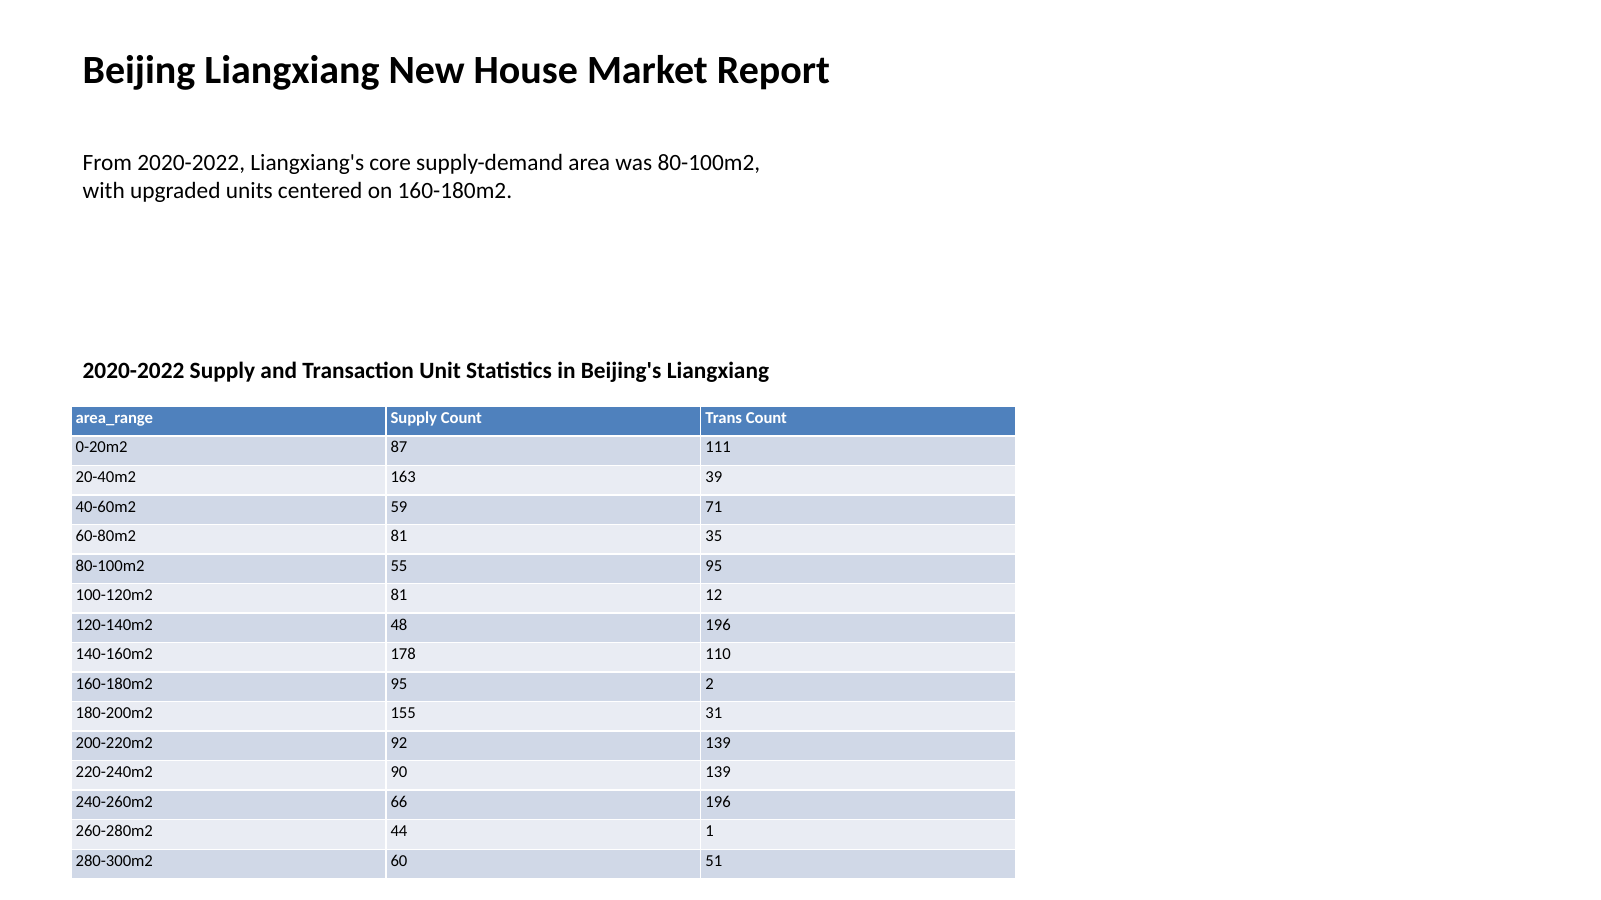

AFTER  — output.pptx


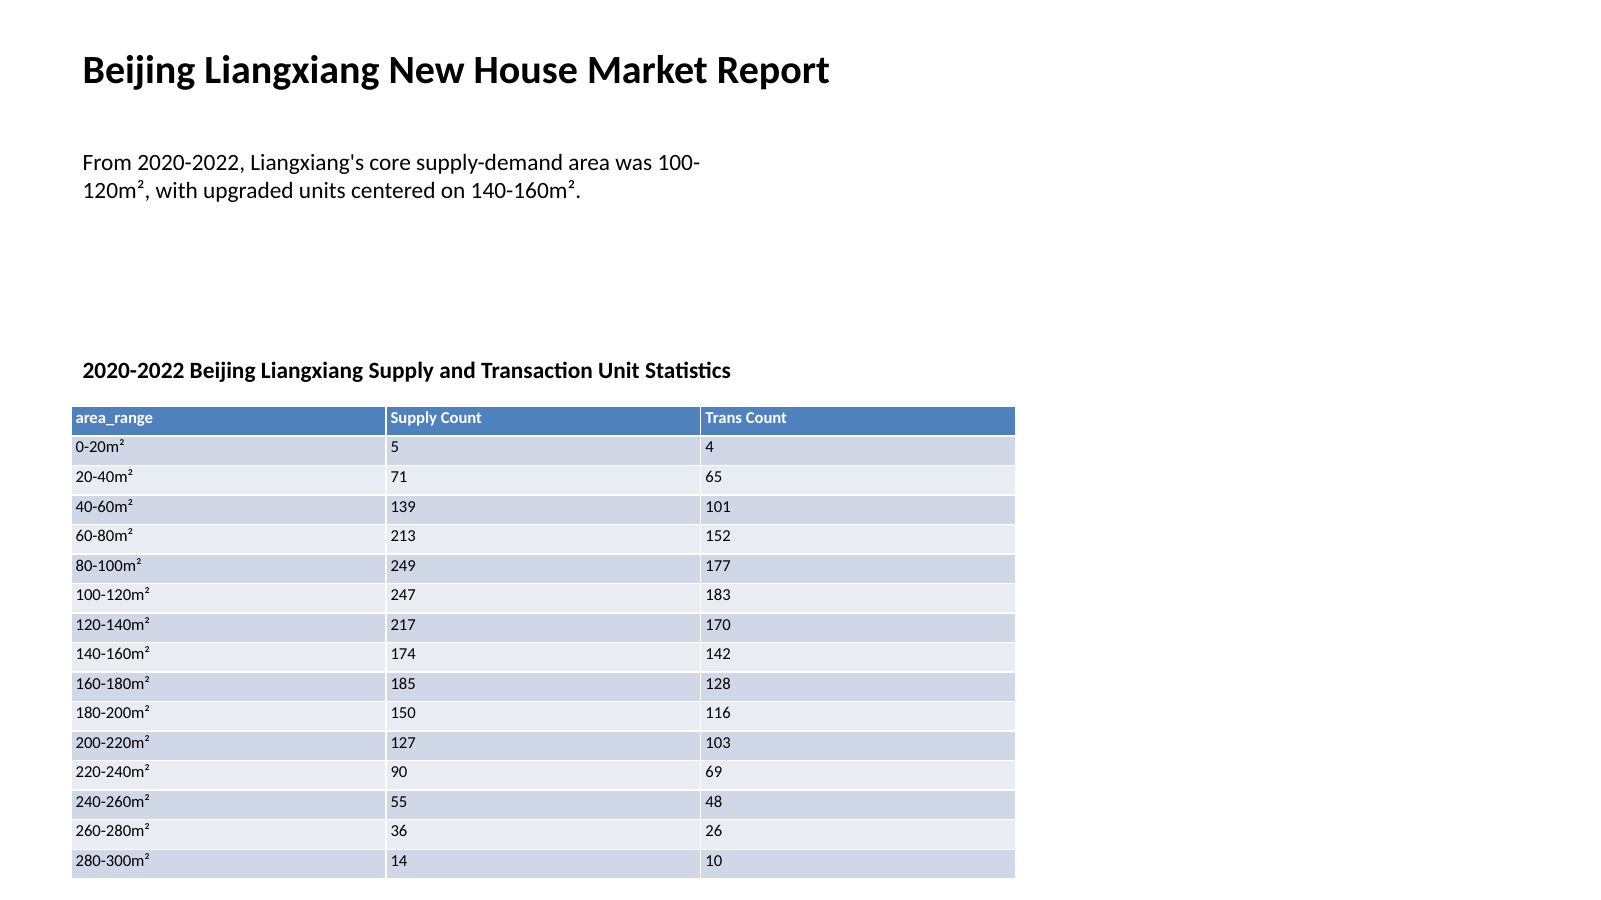

In [9]:
import sys, tempfile
from os.path import join
from IPython.display import Image, display

os.environ["PATH"] = "/Applications/LibreOffice.app/Contents/MacOS" + os.pathsep + "/opt/homebrew/bin" + os.pathsep + os.environ["PATH"]
SKILL = Path("/Users/ngotai/CodeSpace/research_slide_gen/docs/references/openai-slides-skill/scripts")
sys.path.insert(0, str(SKILL))
import render_slides, slides_test

def render_first_png(pptx):
    outdir = pptx.parent / (pptx.stem + "_png")
    dpi = render_slides.calc_dpi_via_ooxml(str(pptx), 1600, 900)
    return render_slides.rasterize(str(pptx), str(outdir), dpi)[0]

print("BEFORE — source.pptx"); display(Image(filename=render_first_png(SRC), width=680))
print("AFTER  — output.pptx"); display(Image(filename=render_first_png(OUT), width=680))

In [10]:
# kiểm tra overflow theo slides_test của skill (render kèm padding xám rồi soi rìa)
from os.path import join
dpi = render_slides.calc_dpi_via_ooxml(str(OUT), 1600, 900)
tmp = tempfile.mkdtemp(); enl = join(tmp, "enlarged.pptx")
pad = slides_test.px_to_emu(slides_test.PAD_PX, dpi)
w1, h1 = slides_test.enlarge_deck(str(OUT), enl, pad)
imgs = render_slides.rasterize(enl, join(tmp, "imgs"), dpi)
fail = slides_test.inspect_images(imgs, pad / w1, pad / h1, dpi)
print("Overflow check output.pptx:", ("FAIL slide " + str(fail)) if fail else "PASS — không tràn khung")

Overflow check output.pptx: PASS — không tràn khung


## 6. Đối chiếu mở rộng: DeckUpdateBench (Repo mới của cùng tác giả)

Ngoài SlideAgent (single-slide), tác giả XiaoZhou2024 còn phát triển **DeckUpdateBench** (`github.com/XiaoZhou2024/DeckUpdateBench`):
- **Bài toán:** Nâng cấp từ cập nhật 1 slide đơn lẻ lên **multi-page report decks** (báo cáo nhiều trang với ràng buộc phụ thuộc giữa các trang và kết luận tổng thể).
- **Dataset Builder:** Cung cấp bộ sinh dữ liệu tự động với 47 template packs (`tpl_01` đến `tpl_48`, thiếu `tpl_16`), kết nối PostgreSQL và ma trận tham số để sinh hàng nghìn cặp `(source.pptx, instruction, target.pptx)`.
- **Hệ thống đánh giá:** Đo lường phân tầng với Task Success Rate (toàn deck), Page Success Rate (từng trang), và Element-Level Accuracy (từng phần tử).
- **Điểm nghẽn chung (Critical Gap):** Cả SlideAgent và DeckAgent (trong DeckUpdateBench) **đều dừng lại ở việc xuất JSON/YAML update plan mà KHÔNG xuất ngược ra file `.pptx` hoàn chỉnh**.
  > *"The current CLI serializes the recovered report state, instruction patch, and element-level update plan to JSON. It does not export a rewritten PPTX in this repository snapshot."*

## 7. Kết luận & hướng phát triển

1. **Lõi thuật toán (Data-grounded update + Fact-aware summary):** Hoạt động chính xác — pipeline đã parse lệnh, sinh SQL, truy vấn Postgres, tính lại bảng và sinh kết luận khớp 100% số liệu.
2. **Giải quyết điểm nghẽn render (B1):** PoC in-place PPTX editing kết hợp agent-skill đã giải quyết trọn vẹn bước sinh `.pptx` giữ nguyên visual layout/font/color và kiểm tra visual QA (không tràn khung).
3. **Hướng đi tiếp theo cho đề tài:**
   - **Mở rộng I/O hoàn chỉnh:** Kết hợp khả năng tạo/chỉnh sửa PPTX từ agent-skill với năng lực data-grounding của SlideAgent/DeckUpdateBench.
   - **Bỏ giả định "kho dữ liệu có sẵn":** Hỗ trợ dữ liệu đầu vào linh hoạt từ Excel đính kèm hoặc structured context do người dùng cung cấp.
   - **Tận dụng Benchmark của DeckUpdateBench:** Có thể sử dụng dataset builder và 47 template packs từ DeckUpdateBench làm testbed chuẩn để đánh giá hệ thống hoàn chỉnh sau khi cải tiến.